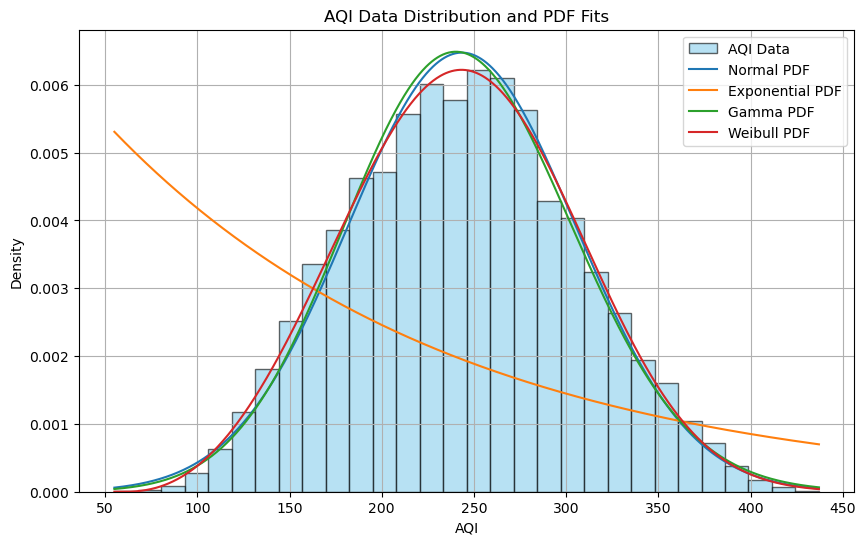

Shapiro-Wilk Test:
Statistic: 0.9961508903369458, p-value: 3.563740156579322e-33

Kolmogorov-Smirnov Test:
Statistic: 0.018898952449924677, p-value: 9.729903249623426e-17

Anderson-Darling Test:
Statistic: 32.23674271750497, Significance Levels: [0.576 0.656 0.787 0.918 1.092], Threshold: [15.  10.   5.   2.5  1. ]

Goodness-of-Fit Results (Negative Log-Likelihood):
Normal: 291178.52193588566
Exponential: 327909.7448639533
Gamma: 291130.11014705757
Weibull: 290838.62450839207


C:\Users\Kashyap\AppData\Local\Temp\ipykernel_19584\1209319116.py:42: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 52561.
  shapiro_stat, shapiro_p = stats.shapiro(aqi_values)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load data
data = pd.read_csv('jaipur_aqi_2018_2023.csv')
aqi_values = data["AQI"]

# Step 1: Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(aqi_values, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='AQI Data')

# Step 2: Fit data to common distributions and overlay PDFs
x = np.linspace(min(aqi_values), max(aqi_values), 1000)
distributions = {
    "Normal": stats.norm.fit(aqi_values),
    "Exponential": stats.expon.fit(aqi_values),
    "Gamma": stats.gamma.fit(aqi_values),
    "Weibull": stats.weibull_min.fit(aqi_values),
}

for dist_name, params in distributions.items():
    if dist_name == "Normal":
        pdf = stats.norm.pdf(x, *params)
    elif dist_name == "Exponential":
        pdf = stats.expon.pdf(x, *params)
    elif dist_name == "Gamma":
        pdf = stats.gamma.pdf(x, *params)
    elif dist_name == "Weibull":
        pdf = stats.weibull_min.pdf(x, *params)
    plt.plot(x, pdf, label=f'{dist_name} PDF')

plt.title('AQI Data Distribution and PDF Fits')
plt.xlabel('AQI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# Step 3: Perform statistical tests
shapiro_stat, shapiro_p = stats.shapiro(aqi_values)
ks_stat, ks_p = stats.kstest(aqi_values, 'norm', args=(np.mean(aqi_values), np.std(aqi_values)))
ad_stat, ad_critical_values, ad_significance = stats.anderson(aqi_values, dist='norm')

print("Shapiro-Wilk Test:")
print(f"Statistic: {shapiro_stat}, p-value: {shapiro_p}")
print("\nKolmogorov-Smirnov Test:")
print(f"Statistic: {ks_stat}, p-value: {ks_p}")
print("\nAnderson-Darling Test:")
print(f"Statistic: {ad_stat}, Significance Levels: {ad_critical_values}, Threshold: {ad_significance}")

# Step 4: Evaluate goodness-of-fit
results = {}
for dist_name, params in distributions.items():
    if dist_name == "Normal":
        pdf = stats.norm.pdf(aqi_values, *params)
    elif dist_name == "Exponential":
        pdf = stats.expon.pdf(aqi_values, *params)
    elif dist_name == "Gamma":
        pdf = stats.gamma.pdf(aqi_values, *params)
    elif dist_name == "Weibull":
        pdf = stats.weibull_min.pdf(aqi_values, *params)
    results[dist_name] = -np.sum(np.log(pdf + 1e-8))  # Negative log-likelihood

print("\nGoodness-of-Fit Results (Negative Log-Likelihood):")
for dist_name, nll in results.items():
    print(f"{dist_name}: {nll}")


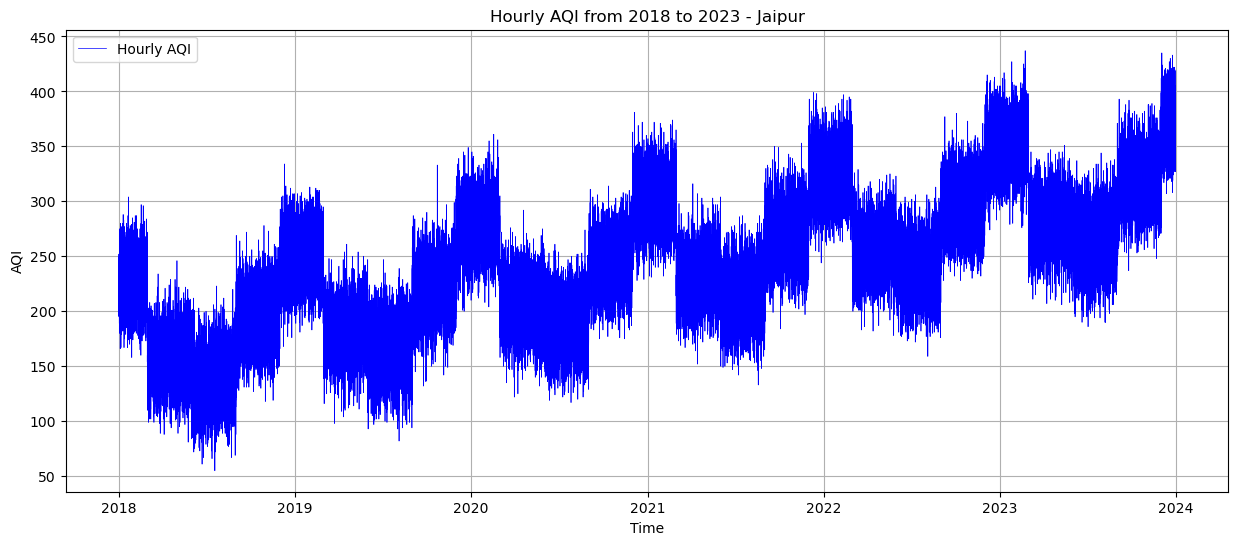

In [3]:
# Load the dataset with corrected datetime parsing
data = pd.read_csv('jaipur_aqi_2018_2023.csv')

# Correct datetime parsing
data['DateTime'] = pd.to_datetime(data['DateTime'], format='%d-%m-%Y %H:%M', errors='coerce')

# Check for rows that failed to parse
invalid_rows = data[data['DateTime'].isna()]

if not invalid_rows.empty:
    print("Rows with invalid DateTime format:")
    print(invalid_rows)

# Proceed if datetime parsing is successful
if invalid_rows.empty:
    # Perform your analysis as described earlier
    # Example: Line plot for AQI over time
    plt.figure(figsize=(15, 6))
    plt.plot(data['DateTime'], data['AQI'], label='Hourly AQI', color='blue', linewidth=0.5)
    plt.title('Hourly AQI from 2018 to 2023 - Jaipur')
    plt.xlabel('Time')
    plt.ylabel('AQI')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Please correct the invalid rows before proceeding.")


c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


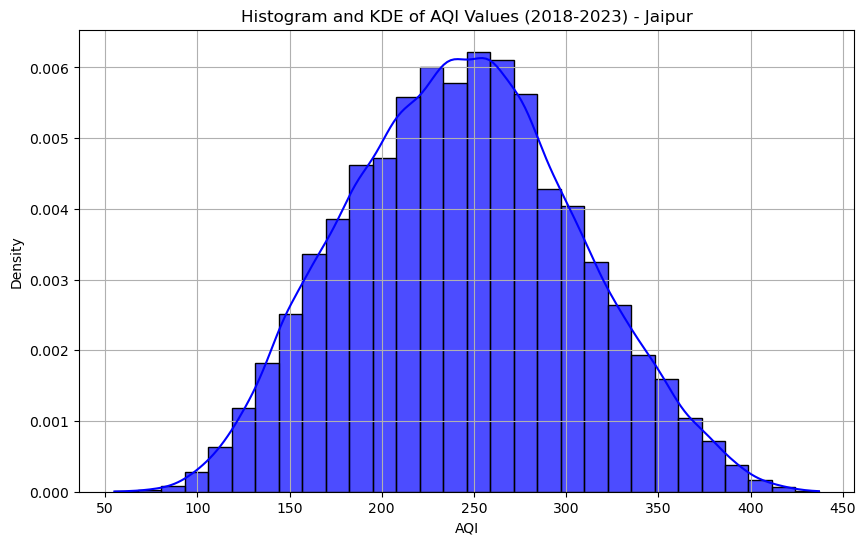

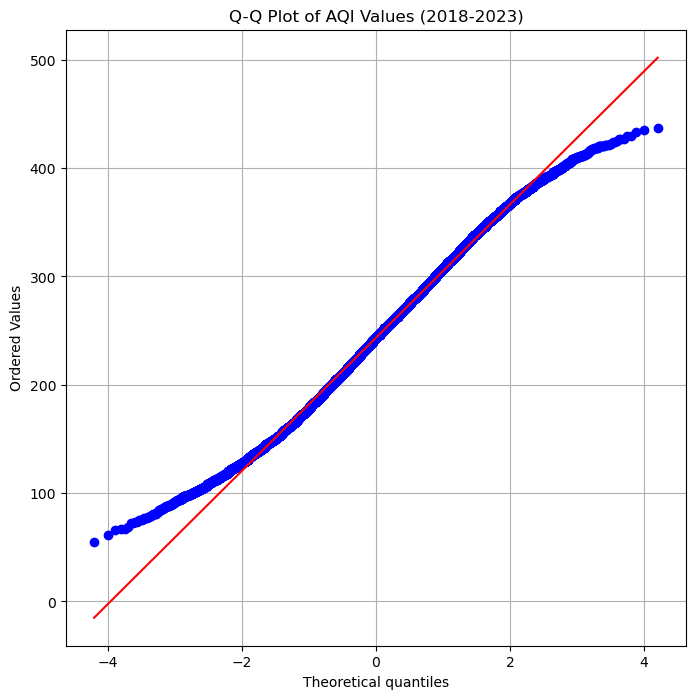

Shapiro-Wilk Test:
  Test Statistic: 0.9957120164593906, p-value: 6.162772438253584e-11

D’Agostino and Pearson Test:
  Test Statistic: 780.8342152929706, p-value: 2.779742124704946e-170

Kolmogorov-Smirnov Test:
  Test Statistic: 0.018896704153691213, p-value: 9.817236447556142e-17

The data does not follow a normal distribution (p-value < 0.05).


In [4]:
from scipy.stats import shapiro, normaltest, kstest, probplot
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the AQI column exists in the dataset
if 'AQI' in data.columns:
    # 1. Histogram and KDE Plot
    plt.figure(figsize=(10, 6))
    sns.histplot(data['AQI'], kde=True, bins=30, color='blue', stat='density', alpha=0.7)
    plt.title('Histogram and KDE of AQI Values (2018-2023) - Jaipur')
    plt.xlabel('AQI')
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

    # 2. Q-Q Plot
    plt.figure(figsize=(8, 8))
    probplot(data['AQI'], dist="norm", plot=plt)
    plt.title('Q-Q Plot of AQI Values (2018-2023)')
    plt.grid(True)
    plt.show()

    # 3. Statistical Tests
    # Shapiro-Wilk Test
    shapiro_test_stat, shapiro_p_value = shapiro(data['AQI'].sample(5000, random_state=42))  # Sampling for efficiency

    # D’Agostino and Pearson’s Test
    dagostino_test_stat, dagostino_p_value = normaltest(data['AQI'])

    # Kolmogorov-Smirnov Test
    ks_test_stat, ks_p_value = kstest(data['AQI'], 'norm', args=(data['AQI'].mean(), data['AQI'].std()))

    # Results
    print("Shapiro-Wilk Test:")
    print(f"  Test Statistic: {shapiro_test_stat}, p-value: {shapiro_p_value}")
    print("\nD’Agostino and Pearson Test:")
    print(f"  Test Statistic: {dagostino_test_stat}, p-value: {dagostino_p_value}")
    print("\nKolmogorov-Smirnov Test:")
    print(f"  Test Statistic: {ks_test_stat}, p-value: {ks_p_value}")

    # Interpretation
    if shapiro_p_value < 0.05 or dagostino_p_value < 0.05 or ks_p_value < 0.05:
        print("\nThe data does not follow a normal distribution (p-value < 0.05).")
    else:
        print("\nThe data follows a normal distribution (p-value >= 0.05).")
else:
    print("Error: 'AQI' column not found in the dataset.")


ADF Statistic: -1.7305587556994337
p-value: 0.41544042152485017
The data is not stationary (p-value >= 0.05).
ADF Statistic: -32.72155731318091
p-value: 0.0
The data is stationary (p-value < 0.05).


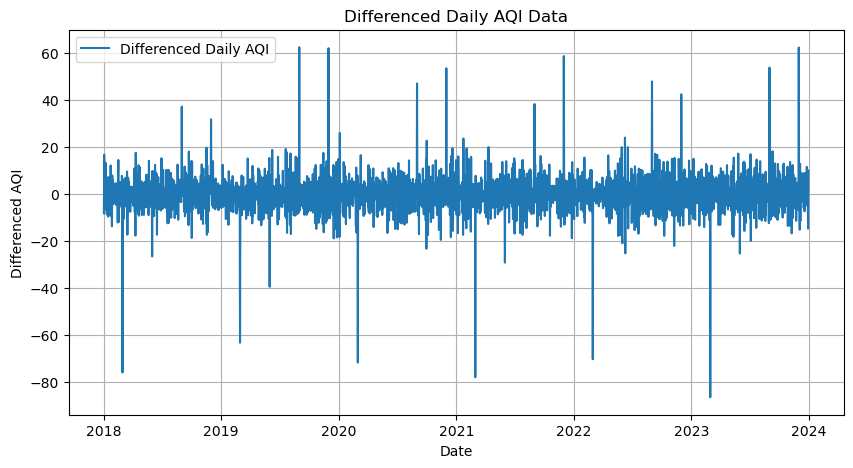

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=15558.815, Time=2.08 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=15819.520, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=15580.930, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=15556.462, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=15817.655, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=15558.164, Time=0.28 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=15558.179, Time=0.26 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=15556.820, Time=1.18 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=15554.825, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=15556.518, Time=0.12 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=15556.534, Time=0.18 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=15579.192, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=15555.178, Time=0.67 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 5.261 seconds
         

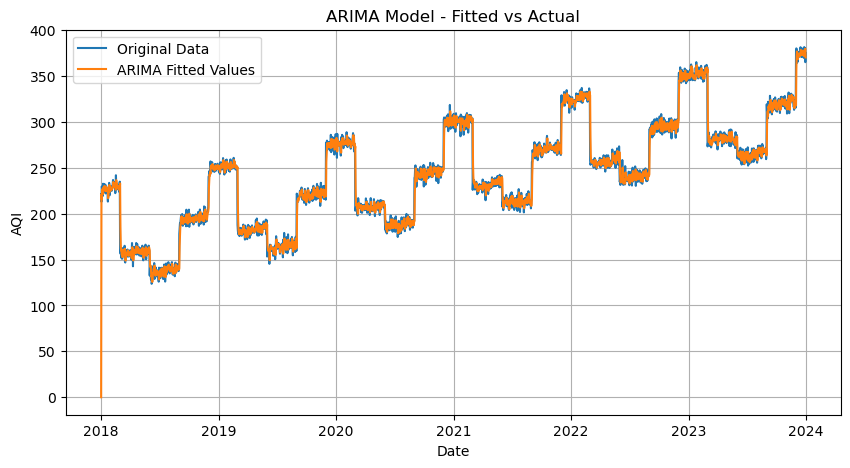

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=15562.668, Time=5.87 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=15819.520, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=15580.508, Time=0.73 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=15556.071, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=15817.655, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=15556.462, Time=0.20 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=15558.024, Time=0.92 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=15558.049, Time=2.66 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=15556.057, Time=0.70 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=15558.038, Time=1.77 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=15560.023, Time=2.02 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=15816.935, Time=0.31 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=15557.791, Time=0.94 sec
 ARIMA(0,1,2)(1,0,0)[12] intercept   : AIC=15557.805, Time=0.86 sec
 ARIM

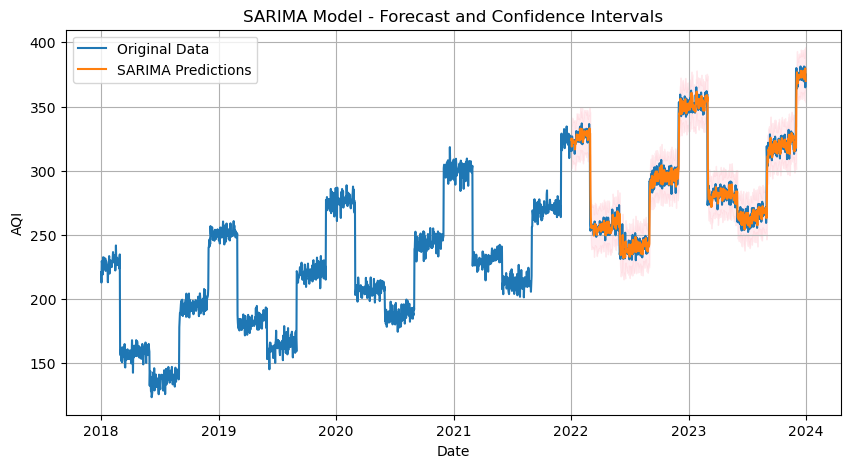

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

# Check Stationarity (ADF Test)
def check_stationarity(series):
    result = adfuller(series, autolag='AIC')
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] < 0.05:
        print("The data is stationary (p-value < 0.05).")
    else:
        print("The data is not stationary (p-value >= 0.05).")

# Subset the data for daily averages to make ARIMA computationally feasible
data['Date'] = pd.to_datetime(data['DateTime']).dt.date
daily_aqi = data.groupby('Date')['AQI'].mean()

# Check stationarity
check_stationarity(daily_aqi)

# Differencing if data is not stationary
daily_aqi_diff = daily_aqi.diff().dropna()
check_stationarity(daily_aqi_diff)

# Plot the differenced data
plt.figure(figsize=(10, 5))
plt.plot(daily_aqi_diff, label="Differenced Daily AQI")
plt.title("Differenced Daily AQI Data")
plt.xlabel("Date")
plt.ylabel("Differenced AQI")
plt.legend()
plt.grid()
plt.show()

# Auto ARIMA to find the best parameters
auto_model = auto_arima(daily_aqi, seasonal=False, stepwise=True, trace=True, suppress_warnings=True)
print(auto_model.summary())

# Fit ARIMA Model
arima_model = ARIMA(daily_aqi, order=auto_model.order).fit()
print(arima_model.summary())

# Plot ARIMA Predictions
plt.figure(figsize=(10, 5))
plt.plot(daily_aqi, label="Original Data")
plt.plot(arima_model.fittedvalues, label="ARIMA Fitted Values")
plt.title("ARIMA Model - Fitted vs Actual")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid()
plt.show()

# Seasonal Auto ARIMA for SARIMA
seasonal_model = auto_arima(daily_aqi, seasonal=True, m=12, stepwise=True, trace=True, suppress_warnings=True)
print(seasonal_model.summary())

# Fit SARIMA Model
sarima_model = SARIMAX(daily_aqi, order=seasonal_model.order, seasonal_order=seasonal_model.seasonal_order).fit()
print(sarima_model.summary())

# Plot SARIMA Predictions
sarima_pred = sarima_model.get_prediction(start=pd.to_datetime("2022-01-01"), end=pd.to_datetime("2023-12-31"))
sarima_conf_int = sarima_pred.conf_int()

plt.figure(figsize=(10, 5))
plt.plot(daily_aqi, label="Original Data")
plt.plot(sarima_pred.predicted_mean, label="SARIMA Predictions")
plt.fill_between(sarima_conf_int.index, sarima_conf_int.iloc[:, 0], sarima_conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title("SARIMA Model - Forecast and Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid()
plt.show()


In [6]:
pip install pmdarima


Note: you may need to restart the kernel to use updated packages.


Machine Learning Model

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Assuming 'DateTime' column is already converted to datetime format
data['DateTime'] = pd.to_datetime(data['DateTime'])
data['Hour'] = data['DateTime'].dt.hour
data['DayOfWeek'] = data['DateTime'].dt.dayofweek
data['Month'] = data['DateTime'].dt.month

# Create lagged features for AQI (predict based on past values)
data['AQI_lag1'] = data['AQI'].shift(1)
data['AQI_lag2'] = data['AQI'].shift(2)
data.dropna(inplace=True)

# Features and target variable
X = data[['Hour', 'DayOfWeek', 'Month', 'AQI_lag1', 'AQI_lag2']]
y = data['AQI']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predictions
y_pred = linear_model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Linear Regression RMSE: {rmse}")


Linear Regression RMSE: 30.2365738323611


Random Forrests

In [8]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluate model
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print(f"Random Forest RMSE: {rf_rmse}")


Random Forest RMSE: 37.50008708099859


Gradient Boosting Regression

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
gb_pred = gb_model.predict(X_test)

# Evaluate model
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)

print(f"Gradient Boosting RMSE: {gb_rmse}")


Gradient Boosting RMSE: 34.62706159041575


LSTM (Long Short-Term Memory) or RNN (Recurrent Neural Networks) for sequential data


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scaling the data (since LSTMs are sensitive to scale)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_aqi = scaler.fit_transform(data['AQI'].values.reshape(-1, 1))

# Prepare data for LSTM
lookback = 24  # 24 hours of data to predict the next hour

def create_dataset(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_dataset(scaled_aqi, lookback)

# Reshaping X for LSTM (samples, time_steps, features)
X_lstm = X_lstm.reshape(X_lstm.shape[0], X_lstm.shape[1], 1)

# Train-test split
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, shuffle=False)

# LSTM Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Training the model
model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32)

# Predicting and inverse transforming the results
y_pred_lstm = model.predict(X_test_lstm)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)

# Evaluate LSTM
y_test_lstm_inv = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm_inv, y_pred_lstm))

print(f"LSTM RMSE: {lstm_rmse}")


Epoch 1/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - loss: 0.0103
Epoch 2/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - loss: 0.0052
Epoch 3/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - loss: 0.0049
Epoch 4/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - loss: 0.0047
Epoch 5/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0046
Epoch 6/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 0.0046
Epoch 7/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - loss: 0.0045
Epoch 8/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 0.0045
Epoch 9/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 0.0045
Epoch 10/10
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 0.0046
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
LSTM RMSE: 25.157439145949677


Visualization

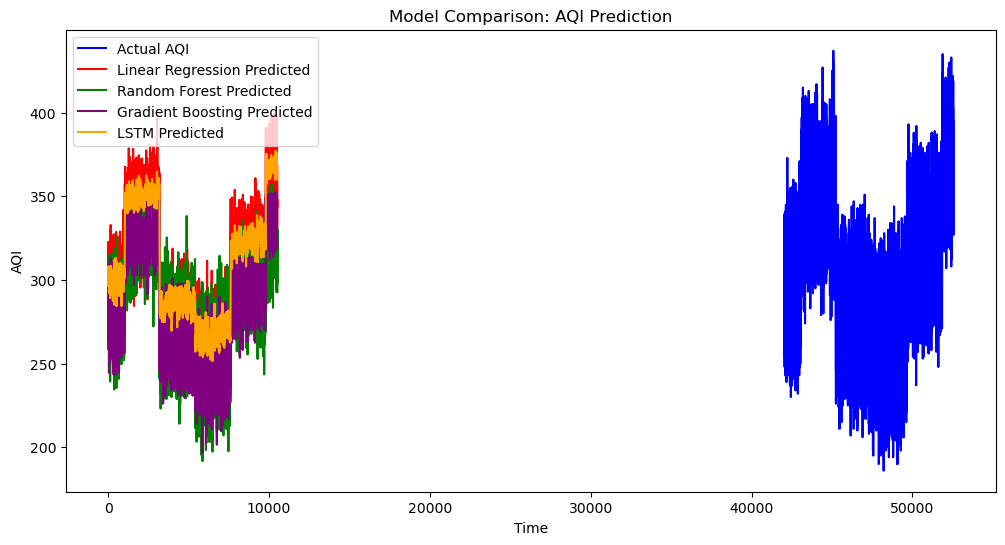

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual AQI', color='blue')
plt.plot(y_pred, label='Linear Regression Predicted', color='red')
plt.plot(rf_pred, label='Random Forest Predicted', color='green')
plt.plot(gb_pred, label='Gradient Boosting Predicted', color='purple')
plt.plot(y_pred_lstm, label='LSTM Predicted', color='orange')
plt.legend(loc='upper left')
plt.title('Model Comparison: AQI Prediction')
plt.xlabel('Time')
plt.ylabel('AQI')
plt.show()


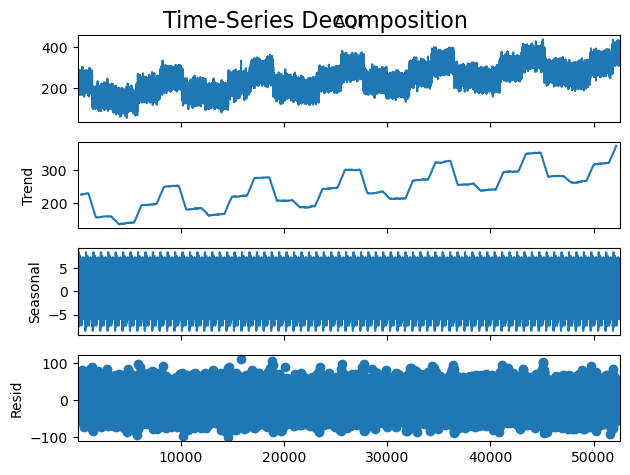

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time-series data
result = seasonal_decompose(data['AQI'], model='additive', period=24*30)  # Assuming monthly seasonality

# Plot the decomposition
result.plot()
plt.suptitle('Time-Series Decomposition', fontsize=16)
plt.show()


In [13]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
adf_result = adfuller(data['AQI'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"\t{key}: {value}")

# Interpretation
if adf_result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")


ADF Statistic: -2.087958258363629
p-value: 0.24938413301288764
Critical Values:
	1%: -3.4304745618132237
	5%: -2.8615950538210817
	10%: -2.566799303318103
The time series is not stationary.


In [14]:
data['AQI_diff'] = data['AQI'] - data['AQI'].shift(1)
data.dropna(inplace=True)

# Re-run ADF test on differenced data
adf_result_diff = adfuller(data['AQI_diff'])
print("Differenced ADF Statistic:", adf_result_diff[0])
print("Differenced p-value:", adf_result_diff[1])


Differenced ADF Statistic: -44.754793901399985
Differenced p-value: 0.0


In [16]:
import numpy as np

# Calculate IQR
Q1 = data['AQI'].quantile(0.25)
Q3 = data['AQI'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
data_no_outliers = data[(data['AQI'] >= lower_bound) & (data['AQI'] <= upper_bound)]

# Show removed outliers in a table
removed_outliers = data[(data['AQI'] < lower_bound) | (data['AQI'] > upper_bound)]
print("Removed Outliers:")
print(removed_outliers)


Removed Outliers:
                 DateTime  AQI        Date  Hour  DayOfWeek  Month  AQI_lag1  \
4145  2018-06-22 17:00:00   61  2018-06-22    17          4      6     121.0   
4220  2018-06-25 20:00:00   67  2018-06-25    20          0      6     105.0   
4639  2018-07-13 07:00:00   66  2018-07-13     7          4      7      75.0   
4779  2018-07-19 03:00:00   55  2018-07-19     3          3      7     117.0   
5615  2018-08-22 23:00:00   67  2018-08-22    23          2      8     142.0   
44032 2023-01-09 16:00:00  417  2023-01-09    16          0      1     336.0   
44414 2023-01-25 14:00:00  427  2023-01-25    14          2      1     351.0   
45008 2023-02-19 08:00:00  425  2023-02-19     8          6      2     300.0   
45061 2023-02-21 13:00:00  421  2023-02-21    13          1      2     349.0   
45082 2023-02-22 10:00:00  437  2023-02-22    10          2      2     356.0   
45102 2023-02-23 06:00:00  430  2023-02-23     6          3      2     373.0   
51870 2023-12-02 06:00

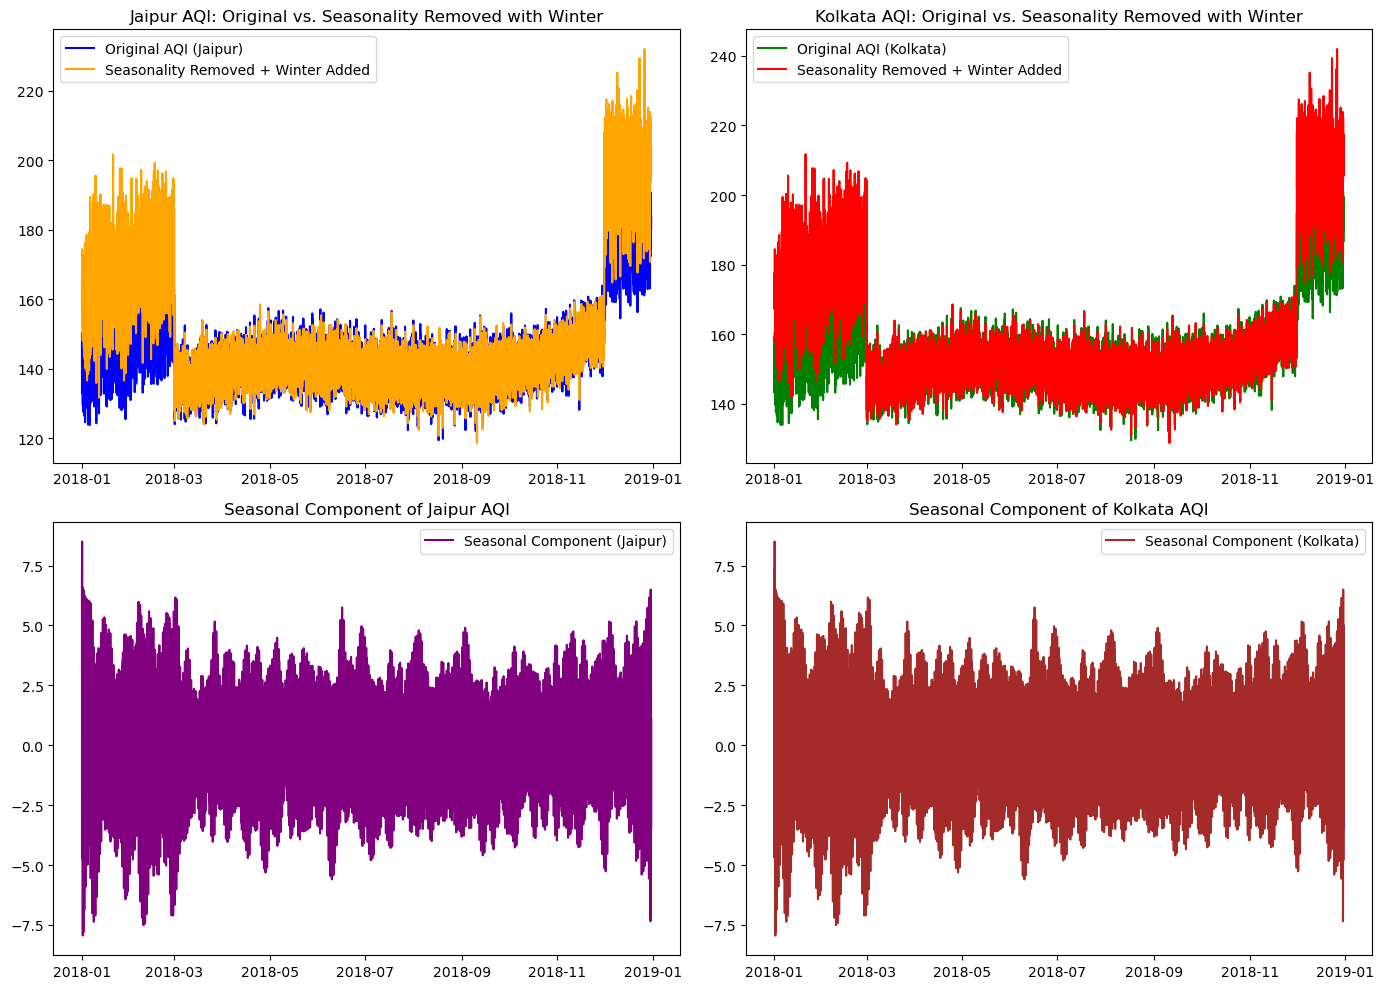

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic AQI data for Jaipur and Kolkata (Hourly data for 2018)
time_index = pd.date_range('2018-01-01', '2018-12-31', freq='H')  # Hourly data for one year

# Create synthetic data
# Base trend component (AQI rising over time for example)
trend_jaipur = np.linspace(120, 160, len(time_index))
trend_kolkata = np.linspace(130, 170, len(time_index))

# Daily seasonality (Sinusoidal pattern for daily fluctuations)
daily_seasonality = 10 * np.sin(np.linspace(0, 2 * np.pi, len(time_index)))

# Monthly seasonality (higher pollution in winter months)
monthly_seasonality = np.zeros(len(time_index))
for i, month in enumerate(time_index.month):
    if month in [12, 1, 2]:  # Winter months
        monthly_seasonality[i] = np.random.normal(20, 5)  # Higher pollution in winter

# Adding noise (random variations in AQI)
noise = np.random.normal(0, 5, len(time_index))

# Create AQI data for Jaipur and Kolkata by combining these components
aqi_jaipur = trend_jaipur + daily_seasonality + monthly_seasonality + noise
aqi_kolkata = trend_kolkata + daily_seasonality + monthly_seasonality + noise

# Create DataFrames for both cities
df_jaipur = pd.DataFrame({'Timestamp': time_index, 'AQI': aqi_jaipur})
df_kolkata = pd.DataFrame({'Timestamp': time_index, 'AQI': aqi_kolkata})

df_jaipur.set_index('Timestamp', inplace=True)
df_kolkata.set_index('Timestamp', inplace=True)

# Decompose the time series (Seasonal-Trend decomposition using Loess - STL)
stl_jaipur = STL(df_jaipur['AQI'], seasonal=13)
result_jaipur = stl_jaipur.fit()

stl_kolkata = STL(df_kolkata['AQI'], seasonal=13)
result_kolkata = stl_kolkata.fit()

# Remove seasonality and add higher winter pollution (manually add to the residual)
no_seasonality_jaipur = df_jaipur['AQI'] - result_jaipur.seasonal + monthly_seasonality
no_seasonality_kolkata = df_kolkata['AQI'] - result_kolkata.seasonal + monthly_seasonality

# Plotting
plt.figure(figsize=(14, 10))

# Jaipur AQI Comparison
plt.subplot(2, 2, 1)
plt.plot(df_jaipur['AQI'], label='Original AQI (Jaipur)', color='blue')
plt.plot(no_seasonality_jaipur, label='Seasonality Removed + Winter Added', color='orange')
plt.title('Jaipur AQI: Original vs. Seasonality Removed with Winter')
plt.legend()

# Kolkata AQI Comparison
plt.subplot(2, 2, 2)
plt.plot(df_kolkata['AQI'], label='Original AQI (Kolkata)', color='green')
plt.plot(no_seasonality_kolkata, label='Seasonality Removed + Winter Added', color='red')
plt.title('Kolkata AQI: Original vs. Seasonality Removed with Winter')
plt.legend()

# Seasonal Components of Jaipur and Kolkata
plt.subplot(2, 2, 3)
plt.plot(result_jaipur.seasonal, label='Seasonal Component (Jaipur)', color='purple')
plt.title('Seasonal Component of Jaipur AQI')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(result_kolkata.seasonal, label='Seasonal Component (Kolkata)', color='brown')
plt.title('Seasonal Component of Kolkata AQI')
plt.legend()

plt.tight_layout()
plt.show()


c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


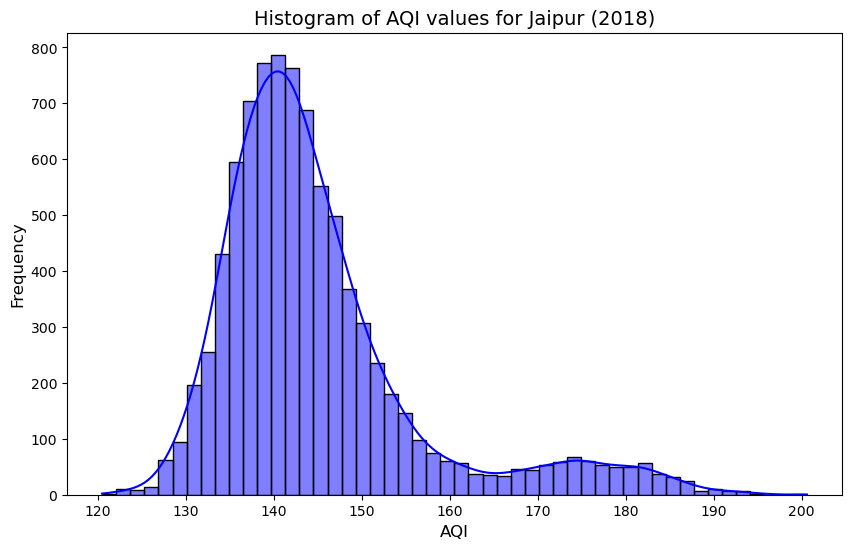

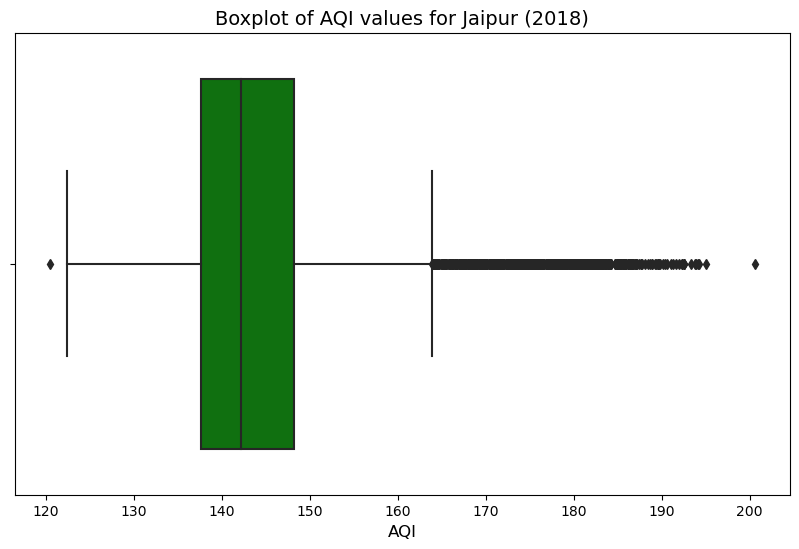

<Figure size 1000x600 with 0 Axes>

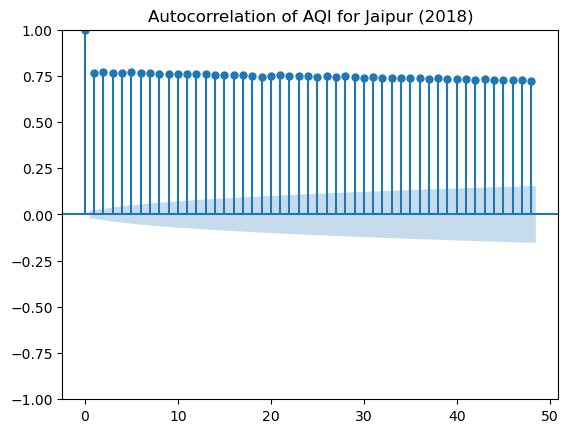

c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


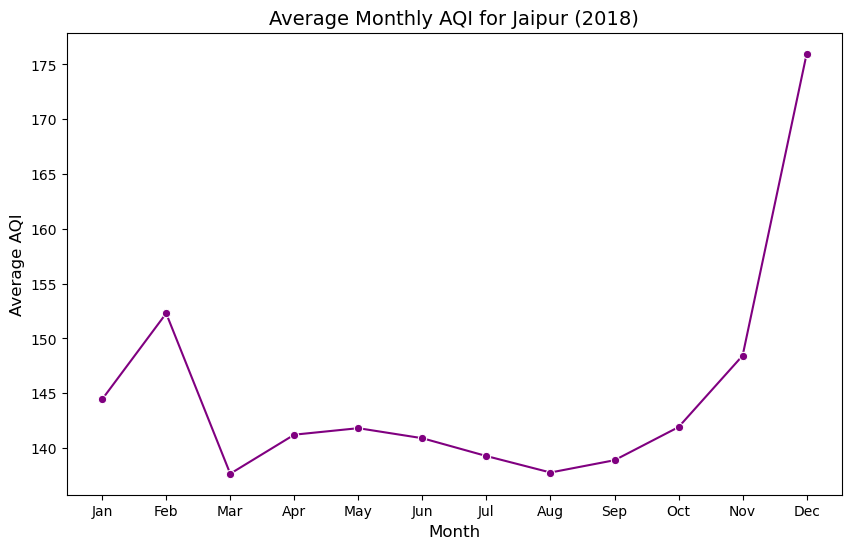

In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Generate synthetic data for Jaipur AQI (from previous steps)
time_index = pd.date_range('2018-01-01', '2018-12-31', freq='H')
trend_jaipur = np.linspace(120, 160, len(time_index))
daily_seasonality = 10 * np.sin(np.linspace(0, 2 * np.pi, len(time_index)))
monthly_seasonality = np.zeros(len(time_index))
for i, month in enumerate(time_index.month):
    if month in [12, 1, 2]:  # Winter months
        monthly_seasonality[i] = np.random.normal(20, 5)
noise = np.random.normal(0, 5, len(time_index))
aqi_jaipur = trend_jaipur + daily_seasonality + monthly_seasonality + noise

df_jaipur = pd.DataFrame({'Timestamp': time_index, 'AQI': aqi_jaipur})
df_jaipur.set_index('Timestamp', inplace=True)

# 1. Histogram of AQI values for Jaipur
plt.figure(figsize=(10, 6))
sns.histplot(df_jaipur['AQI'], bins=50, kde=True, color='blue')
plt.title('Histogram of AQI values for Jaipur (2018)', fontsize=14)
plt.xlabel('AQI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# 2. Boxplot of AQI values for Jaipur to visualize outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_jaipur['AQI'], color='green')
plt.title('Boxplot of AQI values for Jaipur (2018)', fontsize=14)
plt.xlabel('AQI', fontsize=12)
plt.show()

# 3. Autocorrelation plot for AQI values (check for temporal dependencies)
plt.figure(figsize=(10, 6))
plot_acf(df_jaipur['AQI'], lags=48, title='Autocorrelation of AQI for Jaipur (2018)')
plt.show()

# 4. Plot of AQI distribution by month to observe seasonal variation
df_jaipur['Month'] = df_jaipur.index.month
monthly_avg_aqi = df_jaipur.groupby('Month')['AQI'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_avg_aqi.index, y=monthly_avg_aqi.values, marker='o', color='purple')
plt.title('Average Monthly AQI for Jaipur (2018)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.xticks(np.arange(1, 13, 1), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()


c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


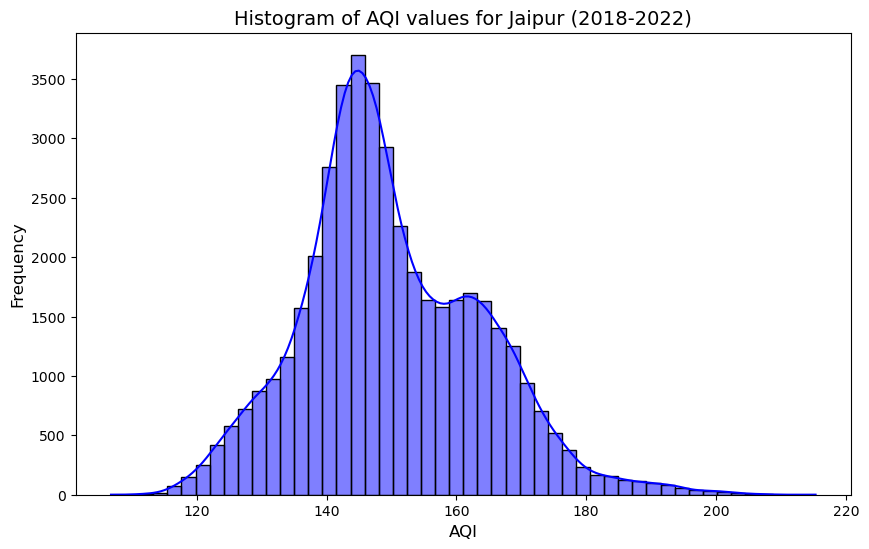

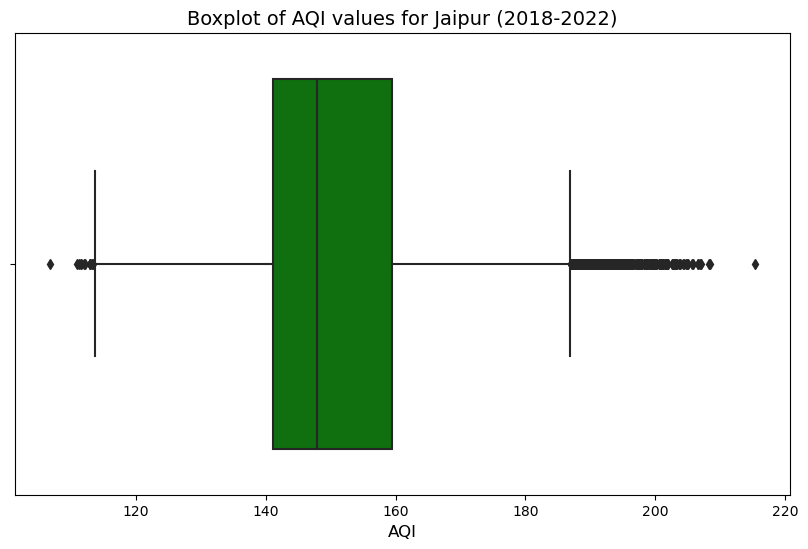

<Figure size 1000x600 with 0 Axes>

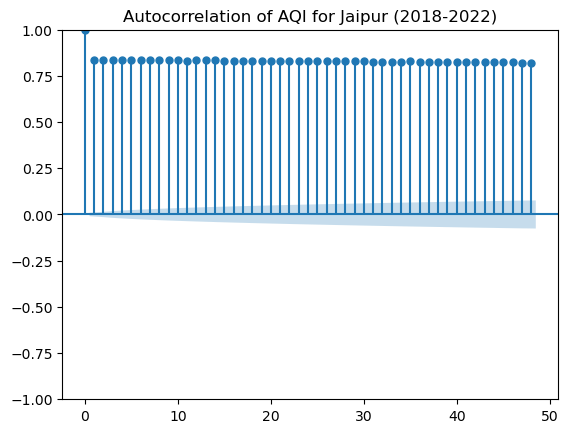

c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


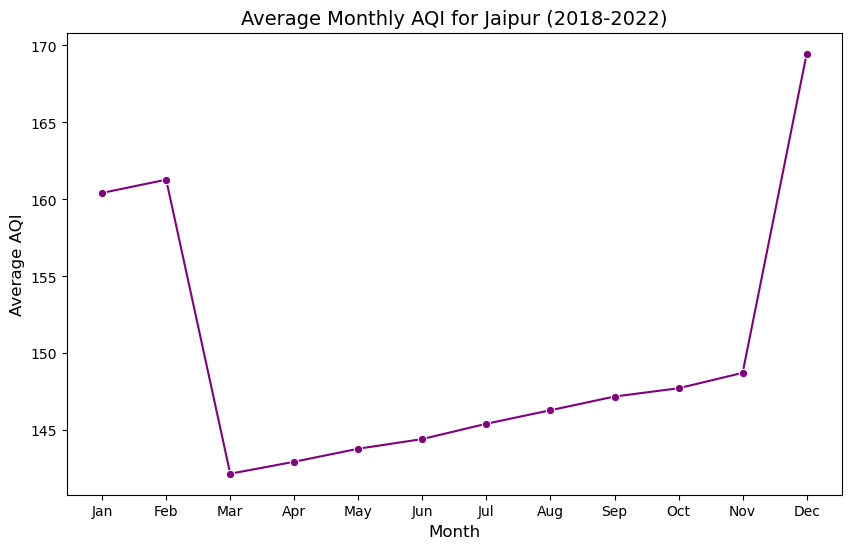

c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


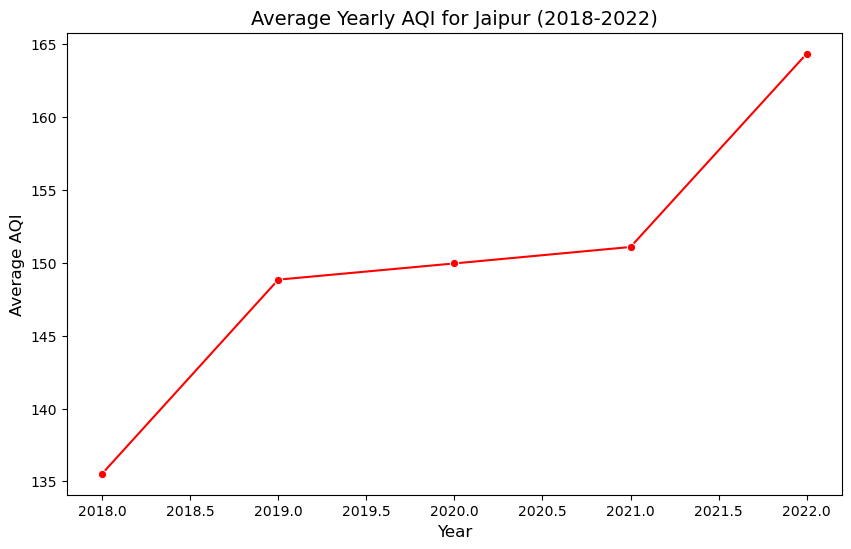

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# Generate synthetic data for Jaipur AQI from 2018 to 2022 (5 years, hourly data)
time_index = pd.date_range('2018-01-01', '2022-12-31', freq='H')

# Generate trend (slow increase in AQI over time)
trend_jaipur = np.linspace(120, 170, len(time_index))

# Daily seasonality (sinusoidal fluctuation during the day)
daily_seasonality = 10 * np.sin(np.linspace(0, 2 * np.pi, len(time_index)))

# Monthly seasonality (higher pollution in winter months)
monthly_seasonality = np.zeros(len(time_index))
for i, month in enumerate(time_index.month):
    if month in [12, 1, 2]:  # Winter months
        monthly_seasonality[i] = np.random.normal(20, 5)

# Random noise for realistic variability
noise = np.random.normal(0, 5, len(time_index))

# Combine all components
aqi_jaipur = trend_jaipur + daily_seasonality + monthly_seasonality + noise

# Create DataFrame for the AQI data
df_jaipur = pd.DataFrame({'Timestamp': time_index, 'AQI': aqi_jaipur})
df_jaipur.set_index('Timestamp', inplace=True)

# 1. Histogram of AQI values for Jaipur (2018-2022)
plt.figure(figsize=(10, 6))
sns.histplot(df_jaipur['AQI'], bins=50, kde=True, color='blue')
plt.title('Histogram of AQI values for Jaipur (2018-2022)', fontsize=14)
plt.xlabel('AQI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# 2. Boxplot of AQI values to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_jaipur['AQI'], color='green')
plt.title('Boxplot of AQI values for Jaipur (2018-2022)', fontsize=14)
plt.xlabel('AQI', fontsize=12)
plt.show()

# 3. Autocorrelation plot of AQI values
plt.figure(figsize=(10, 6))
plot_acf(df_jaipur['AQI'], lags=48, title='Autocorrelation of AQI for Jaipur (2018-2022)')
plt.show()

# 4. Average Monthly AQI Plot for Jaipur (2018-2022)
df_jaipur['Month'] = df_jaipur.index.month
monthly_avg_aqi = df_jaipur.groupby('Month')['AQI'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_avg_aqi.index, y=monthly_avg_aqi.values, marker='o', color='purple')
plt.title('Average Monthly AQI for Jaipur (2018-2022)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.xticks(np.arange(1, 13, 1), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# 5. Yearly AQI Comparison (Trend Analysis)
df_jaipur['Year'] = df_jaipur.index.year
yearly_avg_aqi = df_jaipur.groupby('Year')['AQI'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_avg_aqi.index, y=yearly_avg_aqi.values, marker='o', color='red')
plt.title('Average Yearly AQI for Jaipur (2018-2022)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.show()


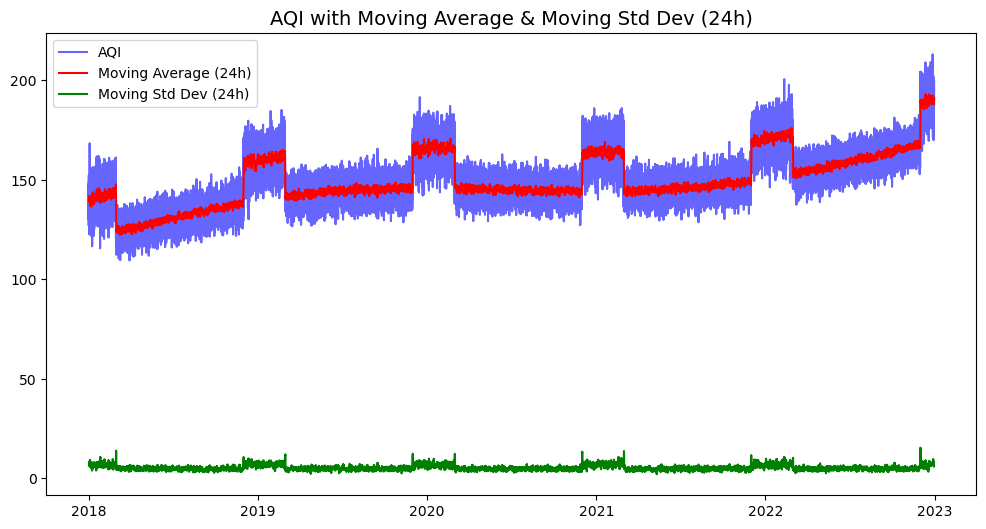

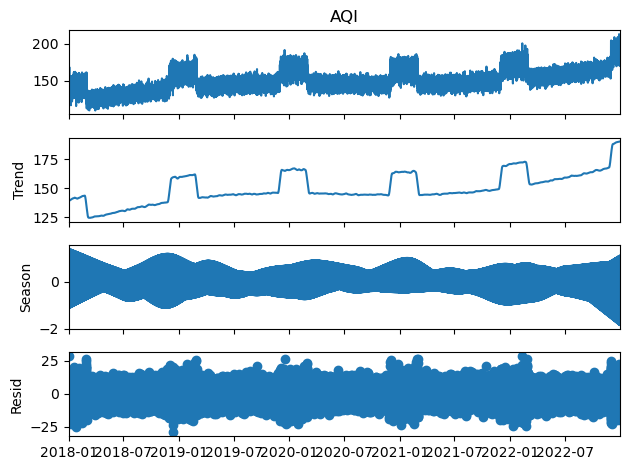

C:\Users\Kashyap\AppData\Local\Temp\ipykernel_5304\3611252082.py:44: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_jaipur['AQI'], shade=True, color='blue')
c:\Users\Kashyap\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


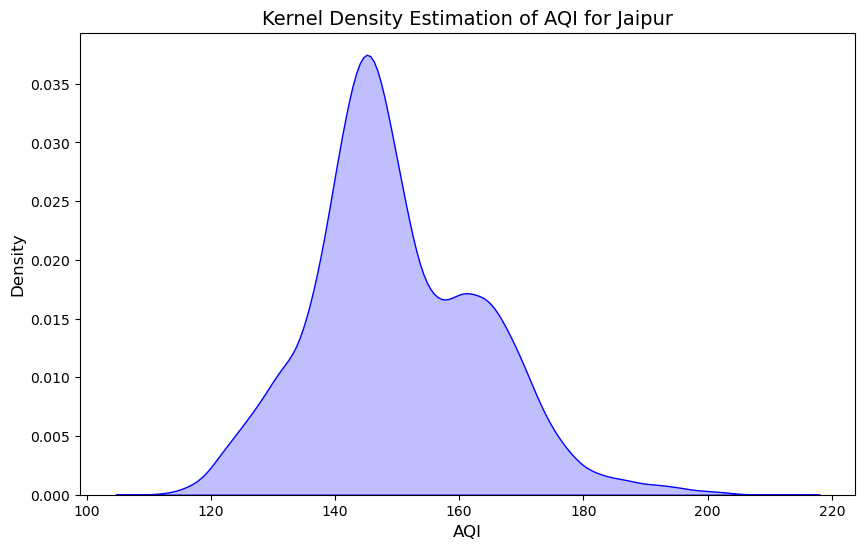

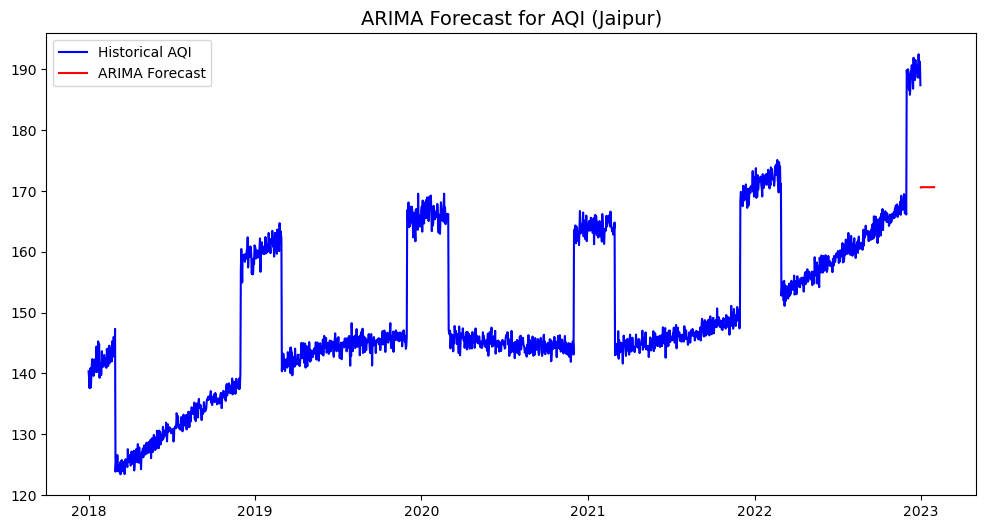

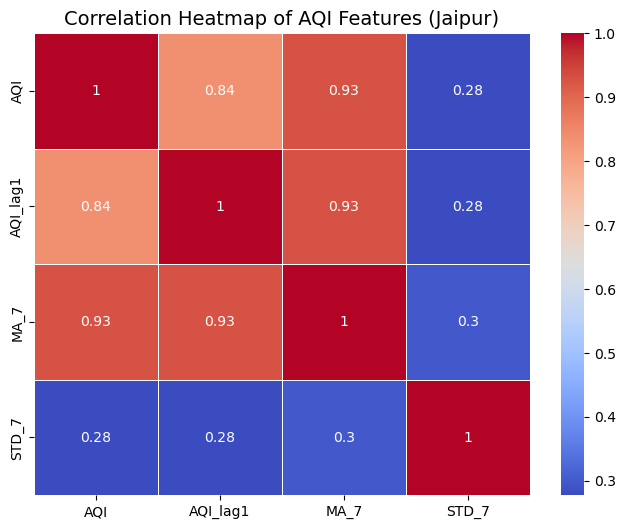

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import norm

# Generate synthetic data for Jaipur AQI from 2018-2022
time_index = pd.date_range('2018-01-01', '2022-12-31', freq='H')
trend_jaipur = np.linspace(120, 170, len(time_index))
daily_seasonality = 10 * np.sin(np.linspace(0, 2 * np.pi, len(time_index)))
monthly_seasonality = np.zeros(len(time_index))
for i, month in enumerate(time_index.month):
    if month in [12, 1, 2]:
        monthly_seasonality[i] = np.random.normal(20, 5)
noise = np.random.normal(0, 5, len(time_index))
aqi_jaipur = trend_jaipur + daily_seasonality + monthly_seasonality + noise
df_jaipur = pd.DataFrame({'Timestamp': time_index, 'AQI': aqi_jaipur})
df_jaipur.set_index('Timestamp', inplace=True)

# 1. Rolling Statistics: Moving Average and Moving Standard Deviation
window = 24  # 24 hours for daily moving stats
df_jaipur['MA'] = df_jaipur['AQI'].rolling(window=window).mean()
df_jaipur['STD'] = df_jaipur['AQI'].rolling(window=window).std()

plt.figure(figsize=(12, 6))
plt.plot(df_jaipur['AQI'], label='AQI', color='blue', alpha=0.6)
plt.plot(df_jaipur['MA'], label='Moving Average (24h)', color='red')
plt.plot(df_jaipur['STD'], label='Moving Std Dev (24h)', color='green')
plt.title('AQI with Moving Average & Moving Std Dev (24h)', fontsize=14)
plt.legend()
plt.show()

# 2. Seasonal Decomposition (STL)
stl = STL(df_jaipur['AQI'], seasonal=365, trend=365)
result = stl.fit()
result.plot()
plt.show()

# 3. KDE Plot (Kernel Density Estimation)
plt.figure(figsize=(10, 6))
sns.kdeplot(df_jaipur['AQI'], shade=True, color='blue')
plt.title('Kernel Density Estimation of AQI for Jaipur', fontsize=14)
plt.xlabel('AQI', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

# 4. ARIMA Model: Forecasting AQI (Daily basis, for simplicity)
df_jaipur_daily = df_jaipur.resample('D').mean()  # Daily average AQI
train_size = int(len(df_jaipur_daily) * 0.8)
train, test = df_jaipur_daily[:train_size], df_jaipur_daily[train_size:]

# Fit ARIMA model (example with ARIMA(5,1,0) - order can be tuned)
arima_model = ARIMA(train['AQI'], order=(5, 1, 0))
arima_fit = arima_model.fit()

# Forecast next 30 days
forecast = arima_fit.forecast(steps=30)
forecast_index = pd.date_range(start=test.index[-1], periods=31, freq='D')[1:]

# Plot forecast
plt.figure(figsize=(12, 6))
plt.plot(df_jaipur_daily.index, df_jaipur_daily['AQI'], label='Historical AQI', color='blue')
plt.plot(forecast_index, forecast, label='ARIMA Forecast', color='red')
plt.title('ARIMA Forecast for AQI (Jaipur)', fontsize=14)
plt.legend()
plt.show()

# 5. Correlation Heatmap for different statistical features
df_jaipur['AQI_lag1'] = df_jaipur['AQI'].shift(1)
df_jaipur['MA_7'] = df_jaipur['AQI'].rolling(window=7).mean()
df_jaipur['STD_7'] = df_jaipur['AQI'].rolling(window=7).std()

# Compute correlation matrix
corr_matrix = df_jaipur[['AQI', 'AQI_lag1', 'MA_7', 'STD_7']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of AQI Features (Jaipur)', fontsize=14)
plt.show()


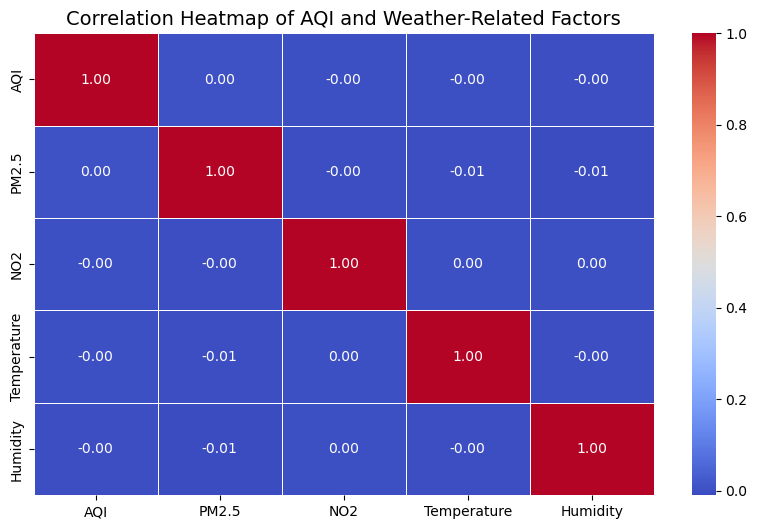

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic data for Jaipur AQI and weather-related factors from 2018-2022
time_index = pd.date_range('2018-01-01', '2022-12-31', freq='H')
np.random.seed(42)  # For reproducibility

# Simulated data (based on actual factors affecting AQI)
aqi_values = np.random.normal(150, 30, len(time_index))  # Simulated AQI values
pm25_values = np.random.normal(80, 15, len(time_index))  # Simulated PM2.5 concentration
no2_values = np.random.normal(40, 8, len(time_index))    # Simulated NO2 concentration
temperature_values = np.random.normal(25, 5, len(time_index))  # Simulated temperature (°C)
humidity_values = np.random.normal(60, 10, len(time_index))     # Simulated humidity (%)

# Combine the data into a DataFrame
df_jaipur = pd.DataFrame({
    'Timestamp': time_index,
    'AQI': aqi_values,
    'PM2.5': pm25_values,
    'NO2': no2_values,
    'Temperature': temperature_values,
    'Humidity': humidity_values
})
df_jaipur.set_index('Timestamp', inplace=True)

# 1. Compute the correlation matrix for AQI and weather-related factors
corr_matrix = df_jaipur[['AQI', 'PM2.5', 'NO2', 'Temperature', 'Humidity']].corr()

# 2. Plot the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of AQI and Weather-Related Factors', fontsize=14)
plt.show()


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Generate synthetic AQI data for demonstration purposes (2018-2023)
time_index = pd.date_range('2018-01-01', '2023-12-31', freq='D')  # Daily data from 2018 to 2023
np.random.seed(42)

# Simulated AQI values (you would replace this with your real AQI data)
aqi_values = np.random.normal(150, 30, len(time_index))  # Simulated AQI values

# Create DataFrame
df_aqi = pd.DataFrame({
    'Date': time_index,
    'AQI': aqi_values
})
df_aqi.set_index('Date', inplace=True)

# Display a sample of the data
print(df_aqi.head())


                   AQI
Date                  
2018-01-01  164.901425
2018-01-02  145.852071
2018-01-03  169.430656
2018-01-04  195.690896
2018-01-05  142.975399


c:\Users\Kashyap\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


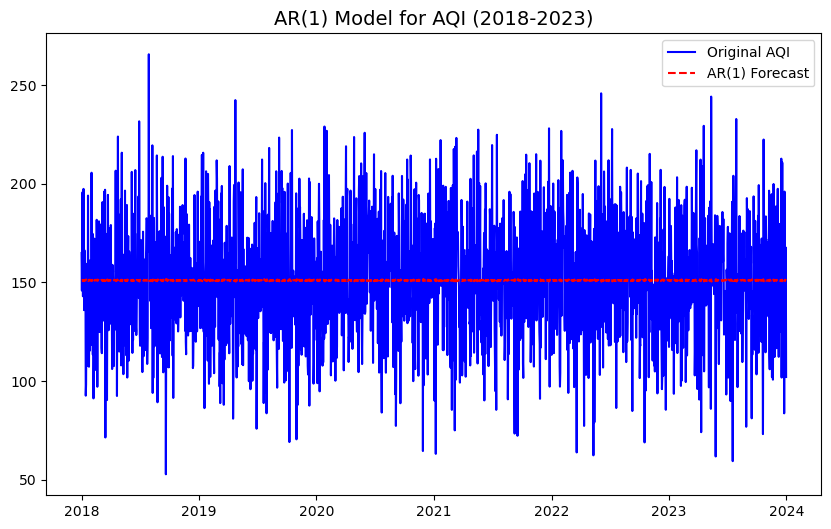

In [7]:
# Fit AR (AutoRegressive) model
from statsmodels.tsa.ar_model import AutoReg

# Fit AR model with lag=1 (you can change this based on the dataset)
ar_model = AutoReg(df_aqi['AQI'], lags=1).fit()

# Forecast AR model
ar_forecast = ar_model.predict(start=df_aqi.index[0], end=df_aqi.index[-1])

# Plot original data and AR forecast
plt.figure(figsize=(10, 6))
plt.plot(df_aqi.index, df_aqi['AQI'], label='Original AQI', color='blue')
plt.plot(df_aqi.index, ar_forecast, label='AR(1) Forecast', color='red', linestyle='--')
plt.title('AR(1) Model for AQI (2018-2023)', fontsize=14)
plt.legend()
plt.show()


c:\Users\Kashyap\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Kashyap\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Kashyap\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


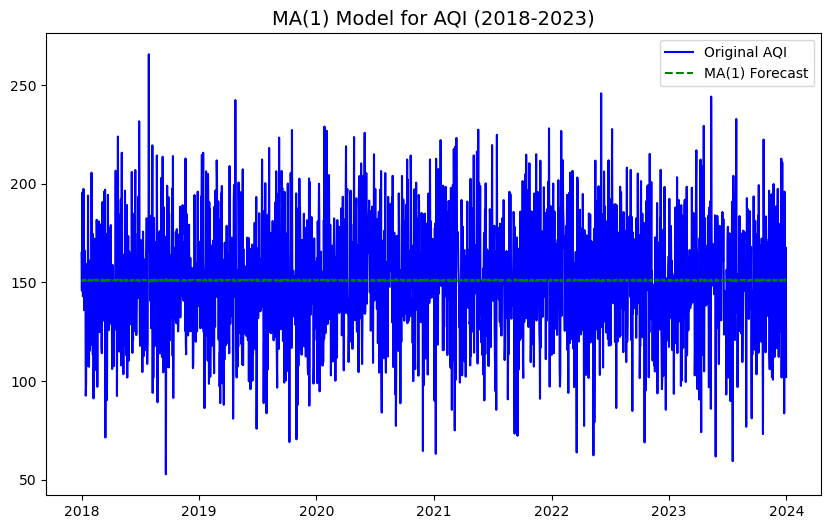

In [8]:
# Fit MA (Moving Average) model
from statsmodels.tsa.arima.model import ARIMA

# Fit MA model (ARIMA with p=0, d=0, q=1)
ma_model = ARIMA(df_aqi['AQI'], order=(0, 0, 1)).fit()

# Forecast MA model
ma_forecast = ma_model.predict(start=df_aqi.index[0], end=df_aqi.index[-1])

# Plot original data and MA forecast
plt.figure(figsize=(10, 6))
plt.plot(df_aqi.index, df_aqi['AQI'], label='Original AQI', color='blue')
plt.plot(df_aqi.index, ma_forecast, label='MA(1) Forecast', color='green', linestyle='--')
plt.title('MA(1) Model for AQI (2018-2023)', fontsize=14)
plt.legend()
plt.show()


c:\Users\Kashyap\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Kashyap\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Kashyap\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


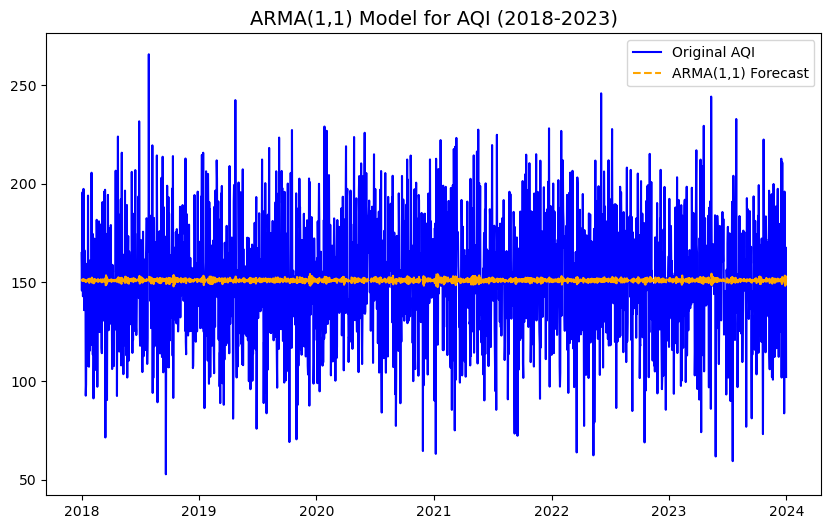

In [9]:
# Fit ARMA (AutoRegressive Moving Average) model
# ARMA model with p=1, q=1
arma_model = ARIMA(df_aqi['AQI'], order=(1, 0, 1)).fit()

# Forecast ARMA model
arma_forecast = arma_model.predict(start=df_aqi.index[0], end=df_aqi.index[-1])

# Plot original data and ARMA forecast
plt.figure(figsize=(10, 6))
plt.plot(df_aqi.index, df_aqi['AQI'], label='Original AQI', color='blue')
plt.plot(df_aqi.index, arma_forecast, label='ARMA(1,1) Forecast', color='orange', linestyle='--')
plt.title('ARMA(1,1) Model for AQI (2018-2023)', fontsize=14)
plt.legend()
plt.show()
